In [1]:
!pip install sqlalchemy pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 7.9 MB/s  0:00:00m 8.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.4/611.4 kB 8.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [sqlalchemy]━━━━━━━ 2/3 [sqlalchemy]


In [46]:
create_table_query = """
CREATE TABLE IF NOT EXISTS tmp_incendie (
    `Annee`                      INT             NOT NULL,
    `Numero`                     INT             NOT NULL,
    `Departement`                VARCHAR(10)     NOT NULL,
    `Insee`                      VARCHAR(10)     NOT NULL,
    `Nom_Commune`          VARCHAR(150)    NULL,
    `Date_Premiere_Alerte`    VARCHAR(30)     NOT NULL,     -- on gardera en VARCHAR pour l'instant
    `Surface_Parcourue`     BIGINT          NOT NULL,
    `Surface_Foret`         DECIMAL(15,2)   NULL,
    `Surface_Maquis_Garrigues` DECIMAL(15,2) NULL,
    `Autres_Surfaces_Naturelles` DECIMAL(15,2) NULL,
    `Surfaces_Agricoles`    DECIMAL(15,2)   NULL,
    `Autres_Surfaces`       DECIMAL(15,2)   NULL,
    `Surface_Autres_Terres_Boisees` DECIMAL(15,2) NULL,
    `Surfaces_Non_Boisees_Naturelles` DECIMAL(15,2) NULL,
    `Surfaces_Non_Boisees_Artificialisees` DECIMAL(15,2) NULL,
    `Surfaces_Non_Boisees`  DECIMAL(15,2)   NULL,
    `Precision_Surfaces`     VARCHAR(100)    NULL,
    `Type_Peuplement`         FLOAT           NULL,
    `Nature`                     VARCHAR(100)    NULL,
    `Deces_BatimentsTouches` VARCHAR(100)    NULL,
    `Nombre_Deces`            SMALLINT        NULL,
    `Nombre_Batiments_Totalement_Detruits` SMALLINT NULL,
    `Nombre_Batiments_Partiellement_Detruits` SMALLINT NULL,
    `Precision_Donnee`     VARCHAR(200)    NULL,
    PRIMARY KEY (`Annee`, `Numero`)
) ENGINE = MyISAM DEFAULT CHARSET = utf8mb4 COLLATE = utf8mb4_unicode_ci;
"""

with engine.connect() as conn:
    conn.execute(text(create_table_query))
    print("✅ Table 'clients' créée")

✅ Table 'clients' créée


In [41]:
import os 

data_folder = "datas"
fichiers_skiprows = {
    "Incendies1971.csv": 3,
    "Incendies1976.csv": 3,
    "Incendies1981.csv": 3,
    "Incendies1986.csv": 3,
    "Incendies1991.csv": 3,
    "Incendies1996.csv": 3,
    "Incendies2001.csv": 3,
    "Incendies2006.csv": 5,
    "Incendies2011.csv": 5,
    "Incendies2016.csv": 3,
    "Incendies2021.csv": 3,
}

all_dfs = []
for fichier, skiprows in fichiers_skiprows.items():
    file = os.path.join(data_folder, fichier)
    try:
        df = pd.read_csv(
            file,
            skiprows=skiprows,
            sep=';',
            encoding='utf-8'
        )
        annee = fichier.replace("Incendies", "").replace(".csv", "")
        
        print(f"{fichier:<25} → skiprows={skiprows:2d} | Lignes={len(df):6,} | Colonnes={len(df.columns)}")
        
        # first_fichier = next(iter(fichiers_skiprows))
        # if fichier == first_fichier:
        #     print("\nAperçu des premières lignes :")
        #     print(df.head(3))
        
        all_dfs.append(df)
    except FileNotFoundError:
        print(f"Fichier non trouvé : {file}")
    except Exception as e:
        print(f"Erreur avec {fichier} : {e}")
print(f"\n {len(all_dfs)} fichiers chargés avec succès !")

Incendies1971.csv         → skiprows= 3 | Lignes= 6,744 | Colonnes=24
Incendies1976.csv         → skiprows= 3 | Lignes=16,701 | Colonnes=24
Incendies1981.csv         → skiprows= 3 | Lignes=15,558 | Colonnes=24
Incendies1986.csv         → skiprows= 3 | Lignes=13,631 | Colonnes=24
Incendies1991.csv         → skiprows= 3 | Lignes=12,906 | Colonnes=24
Incendies1996.csv         → skiprows= 3 | Lignes=12,584 | Colonnes=24
Incendies2001.csv         → skiprows= 3 | Lignes=11,854 | Colonnes=24
Incendies2006.csv         → skiprows= 5 | Lignes=13,246 | Colonnes=24
Incendies2011.csv         → skiprows= 5 | Lignes=12,121 | Colonnes=24
Incendies2016.csv         → skiprows= 3 | Lignes=14,059 | Colonnes=24
Incendies2021.csv         → skiprows= 3 | Lignes=13,380 | Colonnes=24

 11 fichiers chargés avec succès !


In [47]:
def clean_column_names(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)
    rename_dict = {
        "Année": "Annee",
        "Numéro": "Numero",
        "Département": "Departement",
        "Code INSEE": "Insee",
        "Nom de la commune": "Nom_Commune",
        "Date de première alerte": "Date_Premiere_Alerte",
        "Surface parcourue (m2)": "Surface_Parcourue",
        "Surface forêt (m2)": "Surface_Foret",
        "Surface maquis garrigues (m2)": "Surface_Maquis_Garrigues",
        "Autres surfaces naturelles hors forêt (m2)": "Autres_Surfaces_Naturelles",
        "Surfaces agricoles (m2)": "Surfaces_Agricoles",
        "Autres surfaces (m2)": "Autres_Surfaces",
        "Surface autres terres boisées (m2)": "Surface_Autres_Terres_Boisees",
        "Surfaces non boisées naturelles (m2)": "Surfaces_Non_Boisees_Naturelles",
        "Surfaces non boisées artificialisées (m2)": "Surfaces_Non_Boisees_Artificialisees",
        "Surfaces non boisées (m2)": "Surfaces_Non_Boisees",
        "Précision des surfaces": "Precision_Surfaces",
        "Type de peuplement": "Type_Peuplement",
        "Nature": "Nature",
        "Décès ou bâtiments touchés": "Deces_BatimentsTouches",
        "Nombre de décès": "Nombre_Deces",
        "Nombre de bâtiments totalement détruits": "Nombre_Batiments_Totalement_Detruits",
        "Nombre de bâtiments partiellement détruits": "Nombre_Batiments_Partiellement_Detruits",
        "Précision de la donnée": "Precision_Donnee"
    }
    df = df.rename(columns=rename_dict)
    return df

TABLE_NAME = "tmp_incendie"
total_inserted = 0
for i, df in enumerate(all_dfs):
    try:
        df_clean = clean_column_names(df)
        df_clean.to_sql(
                TABLE_NAME, 
                engine, 
                schema="incendies",
                if_exists="append", 
                index=False,
                chunksize=5000
            )
        rows = len(df_clean)
        total_inserted += rows
        print(f"{list(fichiers_skiprows.keys())[i]:<25} → {rows:6,} lignes insérées")
        
    except Exception as e:
        print(f"Erreur insertion {list(fichiers_skiprows.keys())[i]} : {e}")

print(f"\nFIN ! Total inséré dans tmp_incendie : {total_inserted:,} lignes")


Incendies1971.csv         →  6,744 lignes insérées
Incendies1976.csv         → 16,701 lignes insérées
Incendies1981.csv         → 15,558 lignes insérées
Incendies1986.csv         → 13,631 lignes insérées
Incendies1991.csv         → 12,906 lignes insérées
Incendies1996.csv         → 12,584 lignes insérées
Incendies2001.csv         → 11,854 lignes insérées
Incendies2006.csv         → 13,246 lignes insérées
Incendies2011.csv         → 12,121 lignes insérées
Incendies2016.csv         → 14,059 lignes insérées
Incendies2021.csv         → 13,380 lignes insérées

FIN ! Total inséré dans tmp_incendie : 142,784 lignes


In [7]:
TABLE_NAME = 'tmp_incendie'
df = pd.read_sql_table(
    TABLE_NAME,
    engine,
    schema="incendies",
    index_col=None,           # si tu veux une colonne comme index
    chunksize=None,           # None = tout charger d'un coup
    coerce_float=True         # convertit les colonnes numériques
)

print(df.shape)
df.head()

(142784, 24)


,Annee,Numero,Departement,Insee,Nom_Commune,Date_Premiere_Alerte,Surface_Parcourue,Surface_Foret,Surface_Maquis_Garrigues,Autres_Surfaces_Naturelles,...,Surfaces_Non_Boisees_Artificialisees,Surfaces_Non_Boisees,Precision_Surfaces,Type_Peuplement,Nature,Deces_BatimentsTouches,Nombre_Deces,Nombre_Batiments_Totalement_Detruits,Nombre_Batiments_Partiellement_Detruits,Precision_Donnee
0,1973,1,05,05169,Sorbiers,1973-07-03 05:45:00,100000,47000.0,48000.0,0.0,...,NaN,5000.0,NaN,5.0,Naturelle,NaN,NaN,NaN,NaN,NaN
1,1973,4,05,05048,L'Épine,1973-08-22 15:20:00,20000,9400.0,9600.0,0.0,...,NaN,1000.0,NaN,4.0,Naturelle,NaN,NaN,NaN,NaN,NaN
2,1973,2,05,05178,Ventavon,1973-08-22 16:25:00,10000,4700.0,4800.0,0.0,...,NaN,500.0,NaN,5.0,Naturelle,NaN,NaN,NaN,NaN,NaN
3,1973,3,05,05078,Monêtier-Allemont,1973-08-23 14:15:00,5000,2350.0,2400.0,0.0,...,NaN,250.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,1973,5,05,05127,Rousset,1973-09-15 20:00:00,150000,70500.0,72000.0,0.0,...,NaN,7500.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df = pd.read_sql(
    sql=f"SELECT * FROM incendies.{TABLE_NAME}",   # ou juste TABLE_NAME si la DB est dans l'URL
    con=engine
)
df.head()

,Annee,Numero,Departement,Insee,Nom_Commune,Date_Premiere_Alerte,Surface_Parcourue,Surface_Foret,Surface_Maquis_Garrigues,Autres_Surfaces_Naturelles,...,Surfaces_Non_Boisees_Artificialisees,Surfaces_Non_Boisees,Precision_Surfaces,Type_Peuplement,Nature,Deces_BatimentsTouches,Nombre_Deces,Nombre_Batiments_Totalement_Detruits,Nombre_Batiments_Partiellement_Detruits,Precision_Donnee
0,1973,1,05,05169,Sorbiers,1973-07-03 05:45:00,100000,47000.0,48000.0,0.0,...,NaN,5000.0,NaN,5.0,Naturelle,NaN,NaN,NaN,NaN,NaN
1,1973,4,05,05048,L'Épine,1973-08-22 15:20:00,20000,9400.0,9600.0,0.0,...,NaN,1000.0,NaN,4.0,Naturelle,NaN,NaN,NaN,NaN,NaN
2,1973,2,05,05178,Ventavon,1973-08-22 16:25:00,10000,4700.0,4800.0,0.0,...,NaN,500.0,NaN,5.0,Naturelle,NaN,NaN,NaN,NaN,NaN
3,1973,3,05,05078,Monêtier-Allemont,1973-08-23 14:15:00,5000,2350.0,2400.0,0.0,...,NaN,250.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,1973,5,05,05127,Rousset,1973-09-15 20:00:00,150000,70500.0,72000.0,0.0,...,NaN,7500.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df_list = []

for chunk in pd.read_sql_table(TABLE_NAME, engine, schema="incendies", chunksize=50000):
    df_list.append(chunk)

df = pd.concat(df_list, ignore_index=True)
df.head()

,Annee,Numero,Departement,Insee,Nom_Commune,Date_Premiere_Alerte,Surface_Parcourue,Surface_Foret,Surface_Maquis_Garrigues,Autres_Surfaces_Naturelles,...,Surfaces_Non_Boisees_Artificialisees,Surfaces_Non_Boisees,Precision_Surfaces,Type_Peuplement,Nature,Deces_BatimentsTouches,Nombre_Deces,Nombre_Batiments_Totalement_Detruits,Nombre_Batiments_Partiellement_Detruits,Precision_Donnee
0,1973,1,05,05169,Sorbiers,1973-07-03 05:45:00,100000,47000.0,48000.0,0.0,...,None,5000.0,NaN,5.0,Naturelle,NaN,None,None,None,NaN
1,1973,4,05,05048,L'Épine,1973-08-22 15:20:00,20000,9400.0,9600.0,0.0,...,None,1000.0,NaN,4.0,Naturelle,NaN,None,None,None,NaN
2,1973,2,05,05178,Ventavon,1973-08-22 16:25:00,10000,4700.0,4800.0,0.0,...,None,500.0,NaN,5.0,Naturelle,NaN,None,None,None,NaN
3,1973,3,05,05078,Monêtier-Allemont,1973-08-23 14:15:00,5000,2350.0,2400.0,0.0,...,None,250.0,NaN,1.0,NaN,NaN,None,None,None,NaN
4,1973,5,05,05127,Rousset,1973-09-15 20:00:00,150000,70500.0,72000.0,0.0,...,None,7500.0,NaN,5.0,NaN,NaN,None,None,None,NaN


In [ ]:
print("\nAny missing values?")
n_rows = df.shape[0]

print("=" * 80)
print(f"DataFrame : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print("=" * 80)

missing = df.isnull().sum().sort_values(ascending=True)

for col, val in missing.items():
    if val > 0:                                 # affiche seulement les colonnes avec manquants
        pct = val / n_rows * 100
        print(f"{col:.<45} {val:>8,} / {n_rows:,}     {pct:6.2f}%")


Any missing values?
DataFrame : 142,784 lignes × 24 colonnes
Nom_Commune..................................       27 / 142784       0.02%
Surface_Foret................................    4,650 / 142784       3.26%
Surface_Maquis_Garrigues.....................   24,733 / 142784      17.32%
Surfaces_Non_Boisees.........................   33,298 / 142784      23.32%
Autres_Surfaces_Naturelles...................   35,470 / 142784      24.84%
Type_Peuplement..............................   64,658 / 142784      45.28%
Nature.......................................   91,216 / 142784      63.88%
Surface_Autres_Terres_Boisees................  125,756 / 142784      88.07%
Precision_Surfaces...........................  126,892 / 142784      88.87%
Surfaces_Non_Boisees_Naturelles..............  132,089 / 142784      92.51%
Surfaces_Non_Boisees_Artificialisees.........  132,356 / 142784      92.70%
Deces_BatimentsTouches.......................  135,320 / 142784      94.77%
Surfaces_Agricoles........

In [23]:
DATABASE_NAME='incendies'

create_table_query = """
CREATE TABLE incendies_avec_commune AS
SELECT 
    i.*,
    c.nom_standard,
    c.dep_code,
    c.dep_nom,
    c.latitude_centre,
    c.longitude_centre,
    c.superficie_km2,
    c.population,
    c.densite,
    c.altitude_moyenne,
    c.grille_densite_texte
FROM tmp_incendie i
LEFT JOIN tmp_commune c ON i.Insee = c.code_insee;
"""

with engine.connect() as conn:
    conn.execute(text(f"USE {DATABASE_NAME}"))
    conn.execute(text(create_table_query))
    print("✅ Table 'incendies_avec_commune' créée")

✅ Table 'incendies_avec_commune' créée


In [24]:
TABLE_NAME='incendies_avec_commune'

df_list = []
for chunk in pd.read_sql_table(TABLE_NAME, engine, schema="incendies", chunksize=50000):
    df_list.append(chunk)
df = pd.concat(df_list, ignore_index=True)

print("\nAny missing values?")
n_rows = df.shape[0]

print("=" * 80)
print(f"DataFrame : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print("=" * 80)

missing = df.isnull().sum().sort_values(ascending=True)

for col, val in missing.items():
    if val > 0:                                 # affiche seulement les colonnes avec manquants
        pct = val / n_rows * 100
        print(f"{col:.<45} {val:>8,} / {n_rows:,}     {pct:6.2f}%")


Any missing values?
DataFrame : 142,784 lignes × 34 colonnes
Nom_Commune..................................       27 / 142,784       0.02%
densite......................................      915 / 142,784       0.64%
population...................................      915 / 142,784       0.64%
superficie_km2...............................      915 / 142,784       0.64%
dep_nom......................................      915 / 142,784       0.64%
dep_code.....................................      915 / 142,784       0.64%
nom_standard.................................      915 / 142,784       0.64%
altitude_moyenne.............................      915 / 142,784       0.64%
grille_densite_texte.........................      915 / 142,784       0.64%
longitude_centre.............................    1,761 / 142,784       1.23%
latitude_centre..............................    1,761 / 142,784       1.23%
Surface_Foret................................    4,650 / 142,784       3.26%
Surface_Maquis

In [ ]:
from sqlalchemy import create_engine, text

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import Engine
from sqlalchemy import text
from typing import Optional

# ================== PARAMÈTRES ==================
HOST = "localhost" 
PORT = xxx
USER = "xxx" 
PASSWORD = "xxx"

DATABASE_NAME = "incendies"
TABLE_NAME='incendies_avec_commune'
# ===============================================

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}"
)

# Test de connexion
def test_connection(engine) -> bool:
    try:
        with engine.connect() as conn:
            # Test simple et rapide
            result = conn.execute(text("SELECT VERSION()"))
            version = result.scalar()
            
            # Optionnel : lister les bases de données
            dbs = conn.execute(text("SHOW DATABASES")).fetchall()
            db_list = [db[0] for db in dbs]
            
            print("✅ Connexion réussie !")
            print(f"Version MySQL : {version}")
            print(f"Bases de données disponibles : {db_list}")
            
            return True
            
    except Exception as e:
        print("❌ Erreur de connexion :", e)
        return False

# chargement de la table
def load_table_to_dataframe(
    engine: Engine,
    table_name: str,
    schema: str = DATABASE_NAME,
    chunksize: int = 50000,
) -> pd.DataFrame:
    
    df_list = []
    
    for i, chunk in enumerate(pd.read_sql_table(
        table_name=table_name,
        con=engine,
        schema=schema,
        chunksize=chunksize
    )):
        df_list.append(chunk)

    if not df_list:
        return pd.DataFrame()
    df = pd.concat(df_list, ignore_index=True)
    
    return df

✅ Connexion réussie !
Version MySQL : 5.5.68-MariaDB
Bases de données disponibles : ['information_schema', 'arclight-igor', 'arclight-princeps', 'arclight-quad', 'incendies', 'mysql', 'performance_schema', 'test']


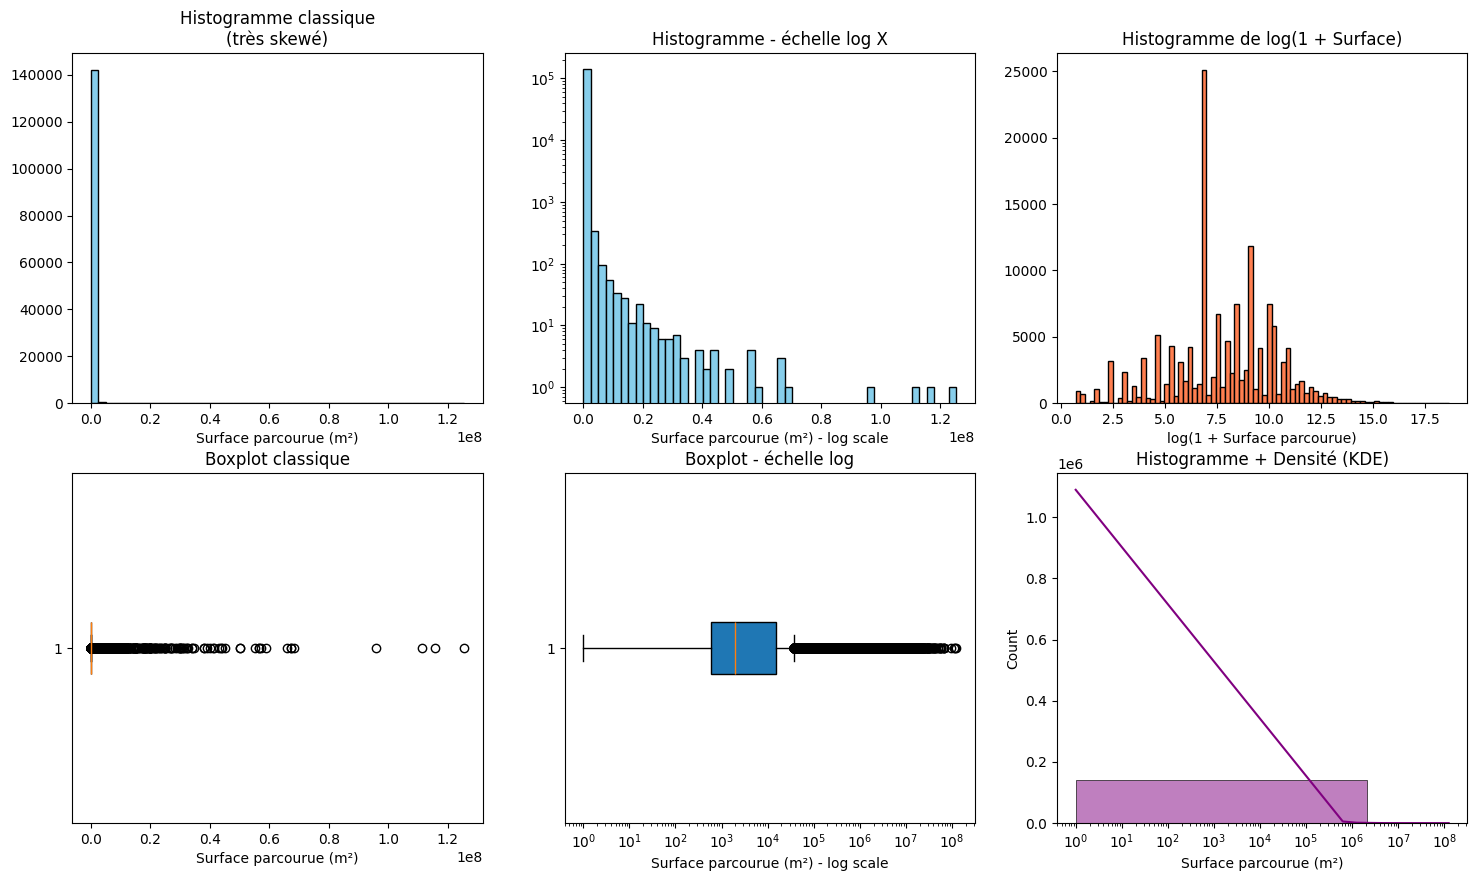

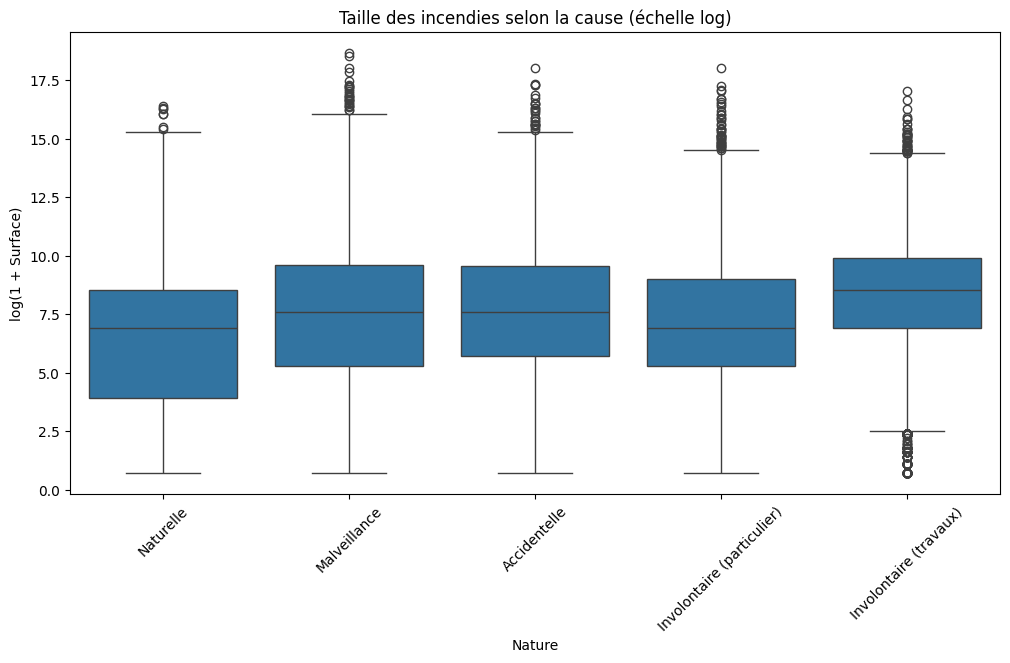

<Figure size 640x480 with 0 Axes>

In [ ]:
# Test Connection
if not test_connection(engine):
    print("Problème de connexion, vérifie tes identifiants.")
else:
    df = pd.DataFrame()
    df = load_table_to_dataframe(engine, TABLE_NAME)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Histogramme classique (pas très utile ici)
axes[0,0].hist(df['Surface_Parcourue'], bins=50, color='skyblue', edgecolor='black')
axes[0,0].set_title('Histogramme classique\n(très skewé)')
axes[0,0].set_xlabel('Surface parcourue (m²)')

# 2. Histogramme avec échelle log sur l'axe X
axes[0,1].hist(df['Surface_Parcourue'], bins=50, color='skyblue', edgecolor='black', log=True)
axes[0,1].set_title('Histogramme - échelle log X')
axes[0,1].set_xlabel('Surface parcourue (m²) - log scale')

# 3. Histogramme sur la variable log-transformée (le plus utile)
surface_log = np.log1p(df['Surface_Parcourue'])  # log(1 + x) pour gérer les 0
axes[0,2].hist(surface_log, bins=80, color='coral', edgecolor='black')
axes[0,2].set_title('Histogramme de log(1 + Surface)')
axes[0,2].set_xlabel('log(1 + Surface parcourue)')

# 4. Boxplot (montre les outliers)
axes[1,0].boxplot(df['Surface_Parcourue'], vert=False, patch_artist=True)
axes[1,0].set_title('Boxplot classique')
axes[1,0].set_xlabel('Surface parcourue (m²)')

# 5. Boxplot en échelle log
axes[1,1].boxplot(df['Surface_Parcourue'], vert=False, patch_artist=True)
axes[1,1].set_xscale('log')
axes[1,1].set_title('Boxplot - échelle log')
axes[1,1].set_xlabel('Surface parcourue (m²) - log scale')

# 6. Histogramme + KDE (très joli avec seaborn)
SS

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Nature', y=np.log1p(df['Surface_Parcourue']))
plt.title('Taille des incendies selon la cause (échelle log)')
plt.ylabel('log(1 + Surface)')
plt.xticks(rotation=45)
plt.show()

plt.tight_layout()
plt.show()

In [5]:
col = 'Surface_Parcourue'

quantiles = [0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 0.999]
stats = df[col].quantile(quantiles).reset_index()
stats.columns = ['Quantile', 'Surface_m2']
stats['Surface_ha'] = stats['Surface_m2'] / 10000
stats['Surface_ha'] = stats['Surface_ha'].round(2)

print(stats.round(2))

   Quantile  Surface_m2  Surface_ha
0      0.50      2000.0        0.20
1      0.75     15000.0        1.50
2      0.90     50000.0        5.00
3      0.95    120000.0       12.00
4      0.99   1000000.0      100.00
5      1.00   2310059.5      231.01
6      1.00  11228680.0     1122.87


In [9]:
df['Surface_Parcourue'].sum() / 10000

np.float64(1079918.1489)

/tmp/ipykernel_5825/3880024509.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Nature', loc='upper right')


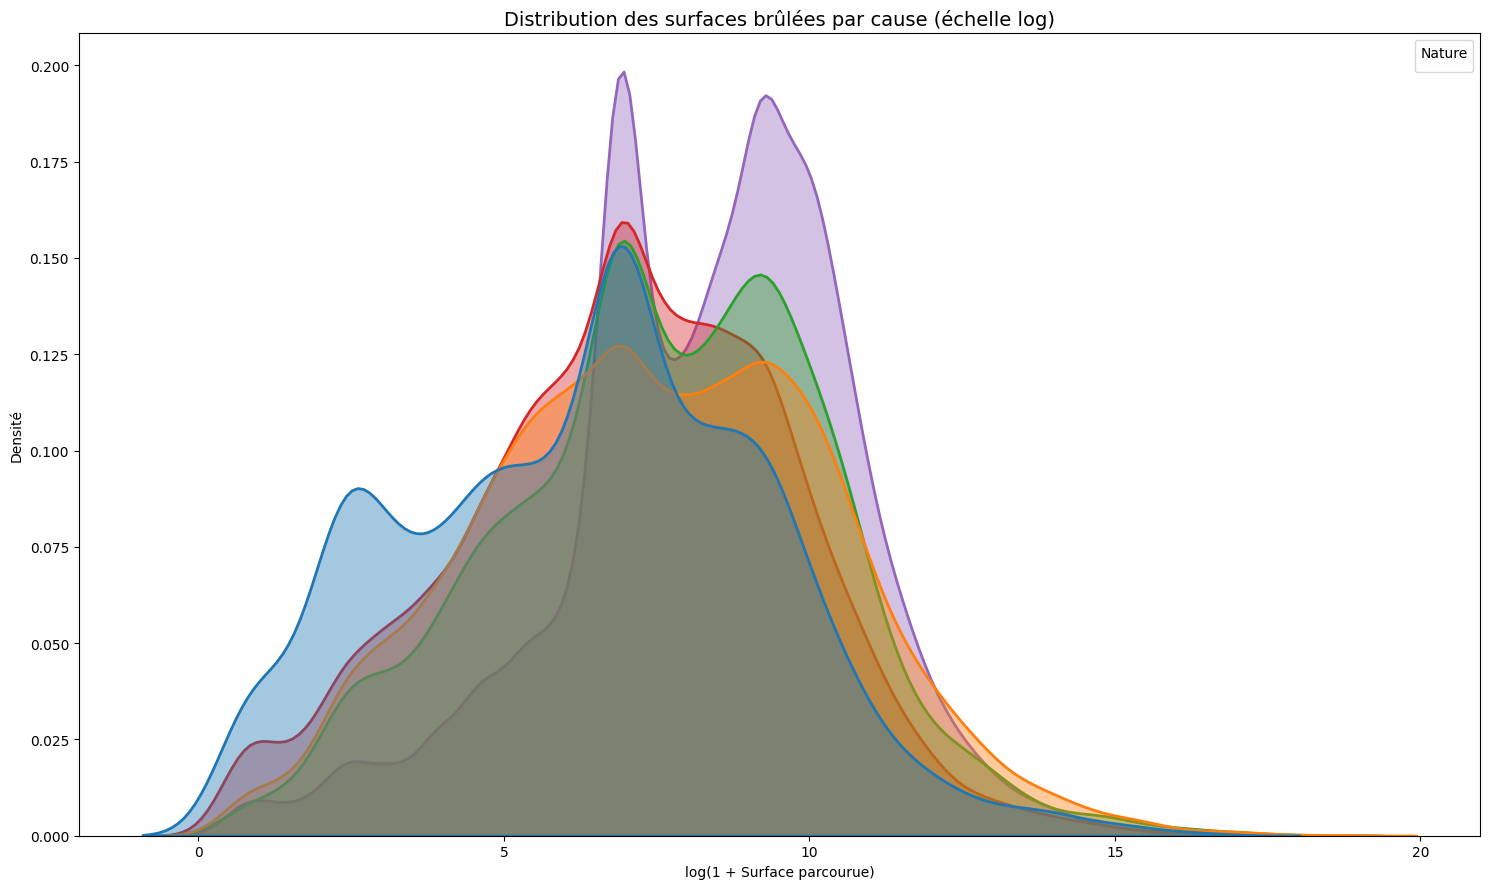

In [13]:
plt.figure(figsize=(15, 9))

# Création du plot
ax = sns.kdeplot(
    data=df,
    x=np.log1p(df['Surface_Parcourue']),
    hue='Nature',
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2,
    palette='tab10'
)

plt.title('Distribution des surfaces brûlées par cause (échelle log)', fontsize=14)
plt.xlabel('log(1 + Surface parcourue)')
plt.ylabel('Densité')

# === SOLUTION POUR FORCER LA LÉGENDE ===
handles, labels = ax.get_legend_handles_labels()
if handles:  # si seaborn a bien créé les handles
    plt.legend(handles, labels, title='Nature', fontsize=11, title_fontsize=12, loc='upper right')
else:
    # Solution de secours si ça ne marche toujours pas
    plt.legend(title='Nature', loc='upper right')

plt.tight_layout()
plt.show()

In [11]:
# Test Connection
if not test_connection(engine):
    print("Problème de connexion, vérifie tes identifiants.")
else:
    df = pd.DataFrame()
    df = load_table_to_dataframe(engine, TABLE_NAME)



✅ Connexion réussie !
Version MySQL : 5.5.68-MariaDB
Bases de données disponibles : ['information_schema', 'arclight-igor', 'arclight-princeps', 'arclight-quad', 'incendies', 'mysql', 'performance_schema', 'test']


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapping détaillé
mapping_vegetation = {
    1.0: 'Maquis / Garrigues / Landes',
    2.0: 'Taillis',
    3.0: 'Futaies Feuillues',
    4.0: 'Futaies Résineuses',
    5.0: 'Futaies Mélangées',
    6.0: 'Régénération / Reboisement',
    np.nan: 'Non renseigné'
}
df['vegetation_type'] = df['Type_Peuplement'].map(mapping_vegetation)

print(round(df['vegetation_type'].value_counts(dropna=False, normalize=True)*100, 2))

vegetation_type
NaN                            45.28
Maquis / Garrigues / Landes    39.67
Futaies Résineuses              5.11
Futaies Mélangées               4.12
Futaies Feuillues               3.69
Régénération / Reboisement      1.14
Taillis                         0.99
Name: proportion, dtype: float64


In [36]:
# Mapping amélioré selon les surfaces réelles observées
df['vegetation_risk_score'] = df['Type_Peuplement'].map({
    0: 7.5,   # Non renseigné → risque assez élevé (on l'a vu sur les graphiques)
    1: 7.0,   # Maquis/Garrigues → fréquent mais pas le plus dangereux
    2: 6.0,   # Taillis
    3: 4.5,   # Futaies Feuillues → moins risqué
    4: 9.0,   # Futaies Résineuses → le plus risqué
    5: 7.5,   # Futaies Mélangées
    6: 8.0    # Régénération / Reboisement → risque élevé
})

# Optionnel : arrondir pour plus de simplicité
df['vegetation_risk_score'] = df['vegetation_risk_score'].round(1)

In [37]:
pd.set_option('display.max_colwidth', None)      # pas de limite sur la largeur d'une colonne
pd.set_option('display.width', 1600)             # largeur totale de la ligne
pd.set_option('display.max_columns', None)       # affiche toutes les colonnes
pd.set_option('display.max_rows', 200)

# 1. Tableau statistique (le plus important)
impact = df.groupby('vegetation_risk_score').agg({
    'Surface_Parcourue': ['count', 'mean', 'median', 'max', 'sum'],
    'Type_Peuplement': 'count'
}).round(2)

impact.columns = ['Nb_incendies', 'Surface_moy_m2', 'Surface_med_m2', 'Surface_max_m2', 'Surface_tot_m2','Type_Peuplement_count']
impact['Surface_moy_ha'] = impact['Surface_moy_m2'] / 10000
impact['Surface_med_ha'] = impact['Surface_med_m2'] / 10000

print(impact)

                       Nb_incendies  Surface_moy_m2  Surface_med_m2  Surface_max_m2  Surface_tot_m2  Type_Peuplement_count  Surface_moy_ha  Surface_med_ha
vegetation_risk_score                                                                                                                                     
4.5                            5266        98656.06          4458.0        56460000       519522809                   5266        9.865606          0.4458
6.0                            1413        47115.43          2000.0        17040000        66574103                   1413        4.711543          0.2000
7.0                           56638        69710.43          3000.0        67440000      3948259234                  56638        6.971043          0.3000
7.5                           70542        71807.91          1600.0       125520000      5065473297                  70542        7.180791          0.1600
8.0                            1624       211131.21          5000.0   

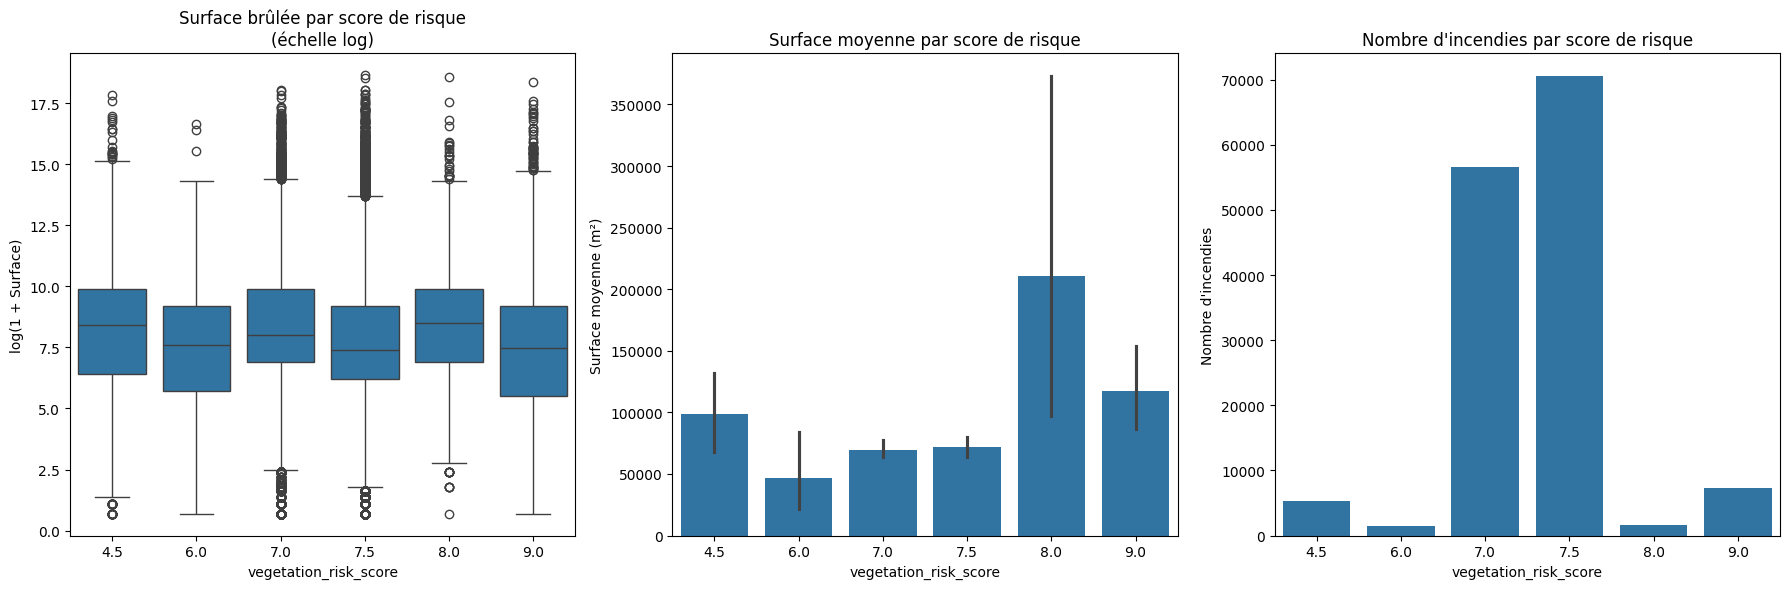

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot : Surface selon le score (échelle log)
sns.boxplot(data=df, x='vegetation_risk_score', y=np.log1p(df['Surface_Parcourue']), ax=axes[0])
axes[0].set_title('Surface brûlée par score de risque\n(échelle log)')
axes[0].set_ylabel('log(1 + Surface)')

# Barplot : Surface moyenne par score
sns.barplot(data=df, x='vegetation_risk_score', y='Surface_Parcourue', estimator='mean', ax=axes[1])
axes[1].set_title('Surface moyenne par score de risque')
axes[1].set_ylabel('Surface moyenne (m²)')

# Nombre d'incendies par score
sns.countplot(data=df, x='vegetation_risk_score', ax=axes[2])
axes[2].set_title("Nombre d'incendies par score de risque")
axes[2].set_ylabel('Nombre d\'incendies')

plt.tight_layout()
plt.show()

In [39]:
# Impact combiné Nature + Score de risque
cross = pd.crosstab(
    df['Nature'].fillna('Non renseignée'), 
    df['vegetation_risk_score'], 
    normalize='index'
) * 100

print("Répartition du score de risque par cause (%) :")
print(cross.round(2))

Répartition du score de risque par cause (%) :
vegetation_risk_score        4.5   6.0    7.0    7.5   8.0    9.0
Nature                                                           
Accidentelle                4.47  1.57  45.22  41.81  1.09   5.85
Involontaire (particulier)  5.44  2.09  47.16  35.80  0.85   8.67
Involontaire (travaux)      5.72  1.26  52.04  33.08  1.51   6.39
Malveillance                5.22  3.13  47.87  31.55  0.99  11.24
Naturelle                   4.72  1.53  29.13  49.42  1.27  13.94
Non renseignée              2.80  0.40  35.73  56.98  1.14   2.96
